Imbalance-aware training and honest evaluation for the Diabetes Prediction project.

Rules that keep the results trustworthy:
  1. The 20% test set is split off FIRST and is never resampled, tuned on, or peeked at
     until the single final evaluation. It keeps the real-world class distribution.
  2. Resampling (random over/under-sampling, SMOTE) happens only on training folds,
     never on validation or test data.
  3. The decision threshold is chosen from out-of-fold predictions on the TRAINING set only.
  4. Model/strategy selection uses out-of-fold PR-AUC (a threshold-free, imbalance-aware metric).

In [1]:
import json, time, warnings
from pathlib import Path

import joblib
import numpy as np
import pandas as pd
import matplotlib
matplotlib.use("Agg")
import matplotlib.pyplot as plt

from sklearn.compose import ColumnTransformer
from sklearn.ensemble import HistGradientBoostingClassifier, RandomForestClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (accuracy_score, average_precision_score, balanced_accuracy_score,
                            brier_score_loss, confusion_matrix, f1_score, matthews_corrcoef,
                            precision_recall_curve, precision_score, recall_score,
                            roc_auc_score, roc_curve)
from sklearn.model_selection import StratifiedKFold, train_test_split
from sklearn.neighbors import NearestNeighbors
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, StandardScaler


In [2]:
warnings.filterwarnings("ignore")
SEED = 42
ROOT = Path.cwd()
DATA = ROOT / "Data" / "diabetes_cleaned.csv"
OUT = ROOT / "results"; FIG = ROOT / "figures"
OUT.mkdir(exist_ok=True); FIG.mkdir(exist_ok=True)

NUM = ["age", "bmi", "HbA1c_level", "blood_glucose_level"]
BIN = ["hypertension", "heart_disease"]
CAT = ["gender", "smoking_history"]
TARGET = "diabetes"

In [3]:
# ----------------------------------------------------------------------------- data
df = pd.read_csv(DATA)
assert df.duplicated().sum() == 0, "duplicates would leak between train and test"
X, y = df.drop(columns=TARGET), df[TARGET].values
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.20, random_state=SEED, stratify=y)
X_train = X_train.reset_index(drop=True); X_test = X_test.reset_index(drop=True)
print(f"train {X_train.shape}  test {X_test.shape}  "
      f"positive rate train={y_train.mean():.4f} test={y_test.mean():.4f}")



train (76916, 8)  test (19230, 8)  positive rate train=0.0882 test=0.0882


In [4]:
def make_preprocessor():
    return ColumnTransformer([
        ("num", StandardScaler(), NUM + BIN),
        ("cat", OneHotEncoder(handle_unknown="ignore", sparse_output=False), CAT)])



In [5]:
# ------------------------------------------------------------------------ resampling
def _balance_counts(y):
    return int((y == 1).sum()), int((y == 0).sum())

In [6]:
def random_oversample(Xd, y, seed):
    rng = np.random.default_rng(seed)
    n_min, n_maj = _balance_counts(y)
    pos = np.flatnonzero(y == 1)
    extra = rng.choice(pos, n_maj - n_min, replace=True)
    idx = np.concatenate([np.arange(len(y)), extra])
    return Xd.iloc[idx].reset_index(drop=True), y[idx]

In [7]:
def random_undersample(Xd, y, seed):
    rng = np.random.default_rng(seed)
    n_min, _ = _balance_counts(y)
    neg = rng.choice(np.flatnonzero(y == 0), n_min, replace=False)
    idx = np.concatenate([np.flatnonzero(y == 1), neg])
    return Xd.iloc[idx].reset_index(drop=True), y[idx]

In [ ]:
def smote(Xd, y, seed, k=5):
    """SMOTE-NC style: interpolate numeric features between a minority sample and one of
    its k nearest minority neighbours; categorical/binary features are copied from the
    base sample (interpolating a category is meaningless)."""
    
    rng = np.random.default_rng(seed)
    n_min, n_maj = _balance_counts(y)
    n_new = n_maj - n_min
    Xm = Xd[y == 1].reset_index(drop=True)

    Z = StandardScaler().fit_transform(Xm[NUM])

    nbr = NearestNeighbors(n_neighbors=k + 1).fit(Z).kneighbors(Z, return_distance=False)[:, 1:]

    base = rng.integers(0, n_min, n_new)
    nb = nbr[base, rng.integers(0, k, n_new)]

    lam = rng.random((n_new, 1))

    new = Xm.iloc[base].reset_index(drop=True).copy()
    b_num = Xm.iloc[base][NUM].to_numpy(float)
    n_num = Xm.iloc[nb][NUM].to_numpy(float)
    new[NUM] = b_num + lam * (n_num - b_num)
    Xo = pd.concat([Xd, new], ignore_index=True)
    yo = np.concatenate([y, np.ones(n_new, dtype=int)])
    return Xo, yo


STRATEGIES = {
    "none":          None,
    "class_weight":  "cw",
    "oversample":    random_oversample,
    "smote":         smote,
    "undersample":   random_undersample,
}

In [9]:
def make_model(name, class_weight):
    cw = "balanced" if class_weight else None
    if name == "LogisticRegression":
        return LogisticRegression(max_iter=2000, class_weight=cw, random_state=SEED)
    if name == "RandomForest":
        return RandomForestClassifier(n_estimators=120, max_depth=12, min_samples_leaf=5,
                                    class_weight=cw, n_jobs=-1, random_state=SEED)
    if name == "HistGradientBoosting":
        return HistGradientBoostingClassifier(max_iter=250, learning_rate=0.08, max_leaf_nodes=15,
                                            l2_regularization=1.0, class_weight=cw,
                                            random_state=SEED)
    raise ValueError(name)

In [10]:
def fit_pipeline(model_name, strategy, Xd, y, seed=SEED):
    """Fit preprocessor+model. Resampling is applied to the (training) data passed in."""
    fn = STRATEGIES[strategy]
    use_cw = fn == "cw"
    if callable(fn):
        Xd, y = fn(Xd, y, seed)
    pipe = Pipeline([("prep", make_preprocessor()), ("model", make_model(model_name, use_cw))])
    pipe.fit(Xd, y)
    return pipe

In [11]:
# ------------------------------------------------------------------------ metrics
def metrics_at(y_true, proba, thr):
    pred = (proba >= thr).astype(int)
    tn, fp, fn, tp = confusion_matrix(y_true, pred, labels=[0, 1]).ravel()
    return {
        "threshold": float(thr),
        "accuracy": accuracy_score(y_true, pred),
        "balanced_accuracy": balanced_accuracy_score(y_true, pred),
        "precision": precision_score(y_true, pred, zero_division=0),
        "recall_sensitivity": recall_score(y_true, pred),
        "specificity": tn / (tn + fp),
        "f1": f1_score(y_true, pred),
        "mcc": matthews_corrcoef(y_true, pred),
        "TN": int(tn), "FP": int(fp), "FN": int(fn), "TP": int(tp),
    }

In [12]:
def threshold_free(y_true, proba):
    return {"roc_auc": roc_auc_score(y_true, proba),
            "pr_auc": average_precision_score(y_true, proba),
            "brier": brier_score_loss(y_true, proba)}


In [14]:
def best_threshold(y_true, proba, objective):
    grid = np.unique(np.round(np.quantile(proba, np.linspace(0.02, 0.995, 400)), 5))
    best_t, best_v = 0.5, -1
    for t in grid:
        p = (proba >= t).astype(int)
        if objective == "balanced_accuracy":
            v = balanced_accuracy_score(y_true, p)
        elif objective == "f1":
            v = f1_score(y_true, p)
        elif objective == "recall90":          # highest specificity subject to recall >= 0.90
            rec = recall_score(y_true, p)
            v = -1 if rec < 0.90 else 1 + (confusion_matrix(y_true, p).ravel()[0] /
                                        (y_true == 0).sum())
        if v > best_v:
            best_t, best_v = float(t), v
    return best_t


In [15]:

# ------------------------------------------------- stage 1: model x strategy sweep (OOF)
def oof_probabilities(model_name, strategy, Xd, y, n_splits=3):
    oof = np.zeros(len(y))
    skf = StratifiedKFold(n_splits, shuffle=True, random_state=SEED)
    for f, (tr, va) in enumerate(skf.split(Xd, y)):
        pipe = fit_pipeline(model_name, strategy, Xd.iloc[tr].reset_index(drop=True), y[tr], SEED + f)
        oof[va] = pipe.predict_proba(Xd.iloc[va])[:, 1]
    return oof


In [16]:

sweep_rows, oof_store = [], {}
t0 = time.time()
for m in ["LogisticRegression", "RandomForest", "HistGradientBoosting"]:
    for s in STRATEGIES:
        oof = oof_probabilities(m, s, X_train, y_train)
        oof_store[(m, s)] = oof
        thr = best_threshold(y_train, oof, "balanced_accuracy")
        row = {"model": m, "strategy": s, **threshold_free(y_train, oof),
               **{f"oof_{k}": v for k, v in metrics_at(y_train, oof, 0.5).items()
                  if k in ("balanced_accuracy", "recall_sensitivity", "precision", "f1", "mcc")},
               "oof_bal_acc_at_tuned_thr": balanced_accuracy_score(y_train, (oof >= thr).astype(int)),
               "tuned_thr": thr}
        sweep_rows.append(row)
        print(f"{m:22s} {s:13s} PR-AUC={row['pr_auc']:.4f} ROC-AUC={row['roc_auc']:.4f} "
              f"BalAcc@0.5={row['oof_balanced_accuracy']:.4f} BalAcc@tuned={row['oof_bal_acc_at_tuned_thr']:.4f} "
              f"[{time.time()-t0:.0f}s]", flush=True)
sweep = pd.DataFrame(sweep_rows).sort_values(["pr_auc", "oof_bal_acc_at_tuned_thr"], ascending=False)
sweep.to_csv(OUT / "01_model_strategy_sweep_oof.csv", index=False)

best = sweep.iloc[0]
BEST_MODEL, BEST_STRAT = best["model"], best["strategy"]
print(f"\nSELECTED (by out-of-fold PR-AUC): {BEST_MODEL} + {BEST_STRAT}", flush=True)


LogisticRegression     none          PR-AUC=0.8199 ROC-AUC=0.9618 BalAcc@0.5=0.8104 BalAcc@tuned=0.8830 [6s]
LogisticRegression     class_weight  PR-AUC=0.8190 ROC-AUC=0.9622 BalAcc@0.5=0.8850 BalAcc@tuned=0.8855 [12s]
LogisticRegression     oversample    PR-AUC=0.8189 ROC-AUC=0.9622 BalAcc@0.5=0.8844 BalAcc@tuned=0.8855 [18s]
LogisticRegression     smote         PR-AUC=0.8189 ROC-AUC=0.9622 BalAcc@0.5=0.8845 BalAcc@tuned=0.8856 [24s]
LogisticRegression     undersample   PR-AUC=0.8185 ROC-AUC=0.9621 BalAcc@0.5=0.8845 BalAcc@tuned=0.8850 [28s]
RandomForest           none          PR-AUC=0.8764 ROC-AUC=0.9714 BalAcc@0.5=0.8334 BalAcc@tuned=0.9044 [46s]
RandomForest           class_weight  PR-AUC=0.8803 ROC-AUC=0.9757 BalAcc@0.5=0.9049 BalAcc@tuned=0.9063 [64s]
RandomForest           oversample    PR-AUC=0.8799 ROC-AUC=0.9755 BalAcc@0.5=0.9060 BalAcc@tuned=0.9066 [92s]
RandomForest           smote         PR-AUC=0.8779 ROC-AUC=0.9749 BalAcc@0.5=0.9033 BalAcc@tuned=0.9060 [121s]
RandomFore

In [17]:

# ------------------------------------------- stage 2: thresholds from OOF (train only)
oof_best = oof_store[(BEST_MODEL, BEST_STRAT)]
THRESHOLDS = {
    "default_0.5": 0.5,
    "balanced (max balanced-accuracy)": best_threshold(y_train, oof_best, "balanced_accuracy"),
    "f1-optimal": best_threshold(y_train, oof_best, "f1"),
    "screening (recall>=90%)": best_threshold(y_train, oof_best, "recall90"),
}
print("thresholds chosen on TRAIN out-of-fold predictions:", {k: round(v, 4) for k, v in THRESHOLDS.items()})


thresholds chosen on TRAIN out-of-fold predictions: {'default_0.5': 0.5, 'balanced (max balanced-accuracy)': 0.4559, 'f1-optimal': 0.8333, 'screening (recall>=90%)': 0.5471}


In [18]:
# ------------------------------- stage 3: 5-fold CV stability of the selected configuration
cv_rows = []
skf = StratifiedKFold(5, shuffle=True, random_state=SEED + 1)
bal_thr = THRESHOLDS["balanced (max balanced-accuracy)"]
for f, (tr, va) in enumerate(skf.split(X_train, y_train)):
    pipe = fit_pipeline(BEST_MODEL, BEST_STRAT, X_train.iloc[tr].reset_index(drop=True), y_train[tr], SEED + f)
    p = pipe.predict_proba(X_train.iloc[va])[:, 1]
    cv_rows.append({"fold": f + 1, **threshold_free(y_train[va], p), **metrics_at(y_train[va], p, bal_thr)})
cv = pd.DataFrame(cv_rows)
cv.to_csv(OUT / "02_cv5_selected_model.csv", index=False)
cv_summary = cv[["accuracy", "balanced_accuracy", "precision", "recall_sensitivity", "specificity",
                 "f1", "mcc", "roc_auc", "pr_auc"]].agg(["mean", "std"]).T
cv_summary.to_csv(OUT / "02b_cv5_summary.csv")
print("\n5-fold CV (train only) mean±std at balanced threshold:\n", cv_summary.round(4), flush=True)



5-fold CV (train only) mean±std at balanced threshold:
                       mean     std
accuracy            0.8955  0.0009
balanced_accuracy   0.9124  0.0023
precision           0.4551  0.0024
recall_sensitivity  0.9328  0.0049
specificity         0.8919  0.0011
f1                  0.6117  0.0025
mcc                 0.6077  0.0030
roc_auc             0.9791  0.0003
pr_auc              0.8877  0.0021


In [19]:

# --------------------------------------------- stage 4: ONE final evaluation on the test set
final = fit_pipeline(BEST_MODEL, BEST_STRAT, X_train, y_train)
p_test = final.predict_proba(X_test)[:, 1]
test_tf = threshold_free(y_test, p_test)

# reference baseline = same algorithm, no imbalance handling, default 0.5 threshold
base_pipe = fit_pipeline(BEST_MODEL, "none", X_train, y_train)
p_base = base_pipe.predict_proba(X_test)[:, 1]

final_rows = [{"config": f"BASELINE {BEST_MODEL} (no balancing) @0.5", **threshold_free(y_test, p_base),
               **metrics_at(y_test, p_base, 0.5)}]
for name, thr in THRESHOLDS.items():
    final_rows.append({"config": f"{BEST_MODEL}+{BEST_STRAT} @ {name}", **test_tf,
                       **metrics_at(y_test, p_test, thr)})
final_df = pd.DataFrame(final_rows)
final_df.to_csv(OUT / "03_final_test_results.csv", index=False)
pd.set_option("display.width", 250); pd.set_option("display.max_columns", 30)
print("\nFINAL TEST SET (untouched, real class distribution):\n",
      final_df.drop(columns=["TN", "FP", "FN", "TP"]).round(4).to_string(index=False), flush=True)



FINAL TEST SET (untouched, real class distribution):
                                                               config  roc_auc  pr_auc  brier  threshold  accuracy  balanced_accuracy  precision  recall_sensitivity  specificity     f1    mcc
                   BASELINE HistGradientBoosting (no balancing) @0.5   0.9778  0.8836 0.0233     0.5000    0.9722             0.8457     0.9890              0.6922       0.9993 0.8144 0.8148
                     HistGradientBoosting+class_weight @ default_0.5   0.9777  0.8835 0.0613     0.5000    0.8993             0.9070     0.4640              0.9163       0.8976 0.6161 0.6086
HistGradientBoosting+class_weight @ balanced (max balanced-accuracy)   0.9777  0.8835 0.0613     0.4559    0.8884             0.9084     0.4377              0.9328       0.8841 0.5959 0.5930
                      HistGradientBoosting+class_weight @ f1-optimal   0.9777  0.8835 0.0613     0.8333    0.9692             0.8579     0.9088              0.7229       0.9930 0.80

In [20]:

# all-model test table (same protocol, each at its own OOF-balanced threshold) for the paper
all_rows = []
for m in ["LogisticRegression", "RandomForest", "HistGradientBoosting"]:
    for s in STRATEGIES:
        thr_ms = best_threshold(y_train, oof_store[(m, s)], "balanced_accuracy")
        pipe = final if (m, s) == (BEST_MODEL, BEST_STRAT) else fit_pipeline(m, s, X_train, y_train)
        pt = pipe.predict_proba(X_test)[:, 1]
        all_rows.append({"model": m, "strategy": s, **threshold_free(y_test, pt),
                         **metrics_at(y_test, pt, thr_ms)})
pd.DataFrame(all_rows).to_csv(OUT / "04_all_configs_test_at_balanced_threshold.csv", index=False)


In [21]:
# bootstrap 95% CIs on the test set at the balanced threshold
rng = np.random.default_rng(SEED)
boots = []
for _ in range(500):
    i = rng.integers(0, len(y_test), len(y_test))
    if y_test[i].min() == y_test[i].max():
        continue
    boots.append({**metrics_at(y_test[i], p_test[i], bal_thr), **threshold_free(y_test[i], p_test[i])})
boot = pd.DataFrame(boots)
ci = boot[["accuracy", "balanced_accuracy", "precision", "recall_sensitivity", "specificity",
           "f1", "mcc", "roc_auc", "pr_auc"]].quantile([0.025, 0.975]).T
ci.columns = ["ci_low", "ci_high"]
ci.to_csv(OUT / "05_bootstrap_ci_test_balanced_threshold.csv")
print("\nBootstrap 95% CI (test, balanced threshold):\n", ci.round(4), flush=True)



Bootstrap 95% CI (test, balanced threshold):
                     ci_low  ci_high
accuracy            0.8841   0.8927
balanced_accuracy   0.9021   0.9148
precision           0.4223   0.4538
recall_sensitivity  0.9217   0.9449
specificity         0.8795   0.8888
f1                  0.5807   0.6107
mcc                 0.5795   0.6063
roc_auc             0.9751   0.9800
pr_auc              0.8715   0.8947


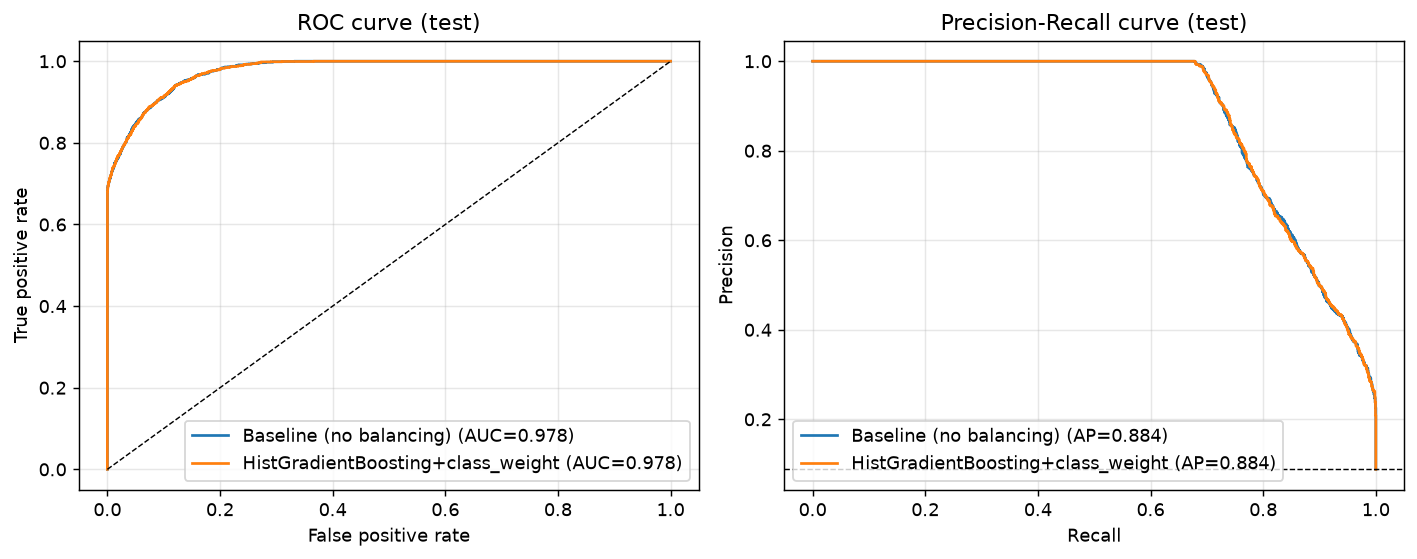

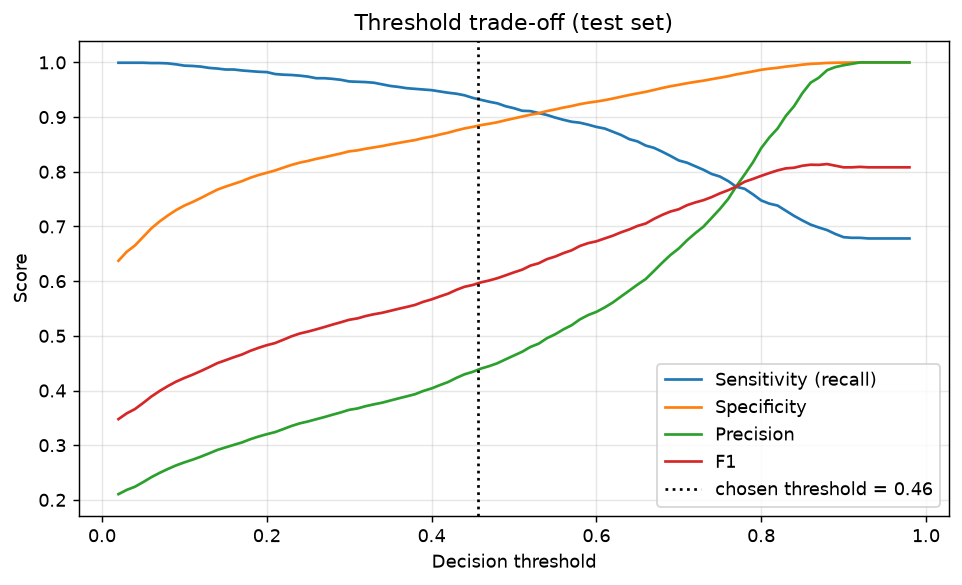

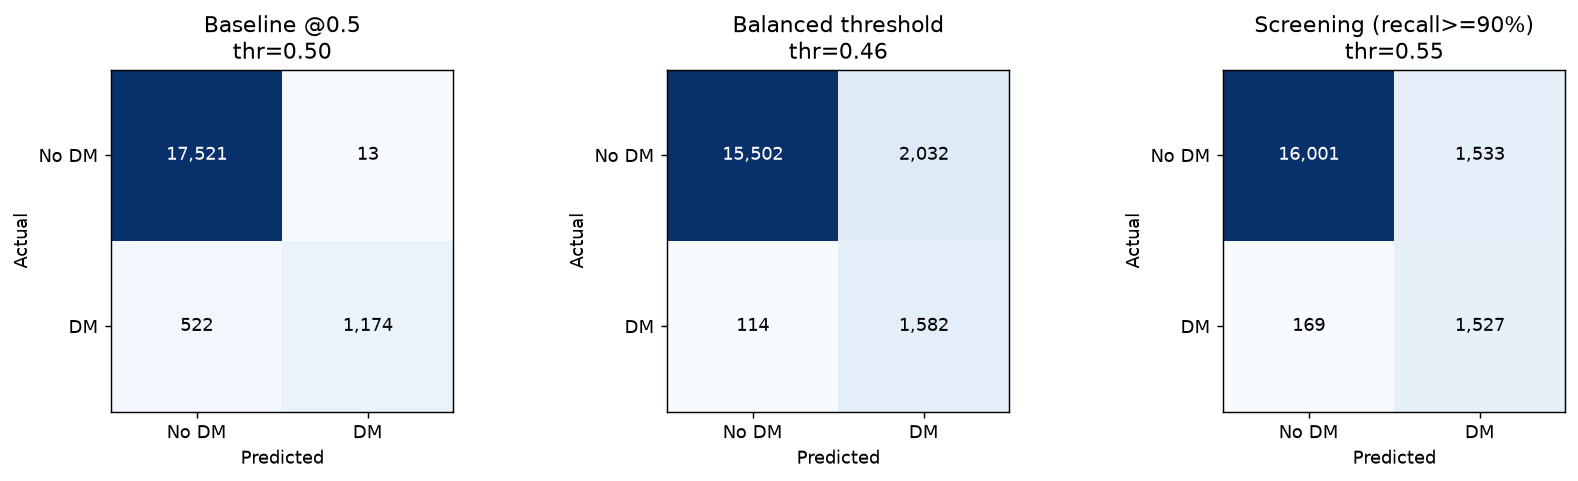

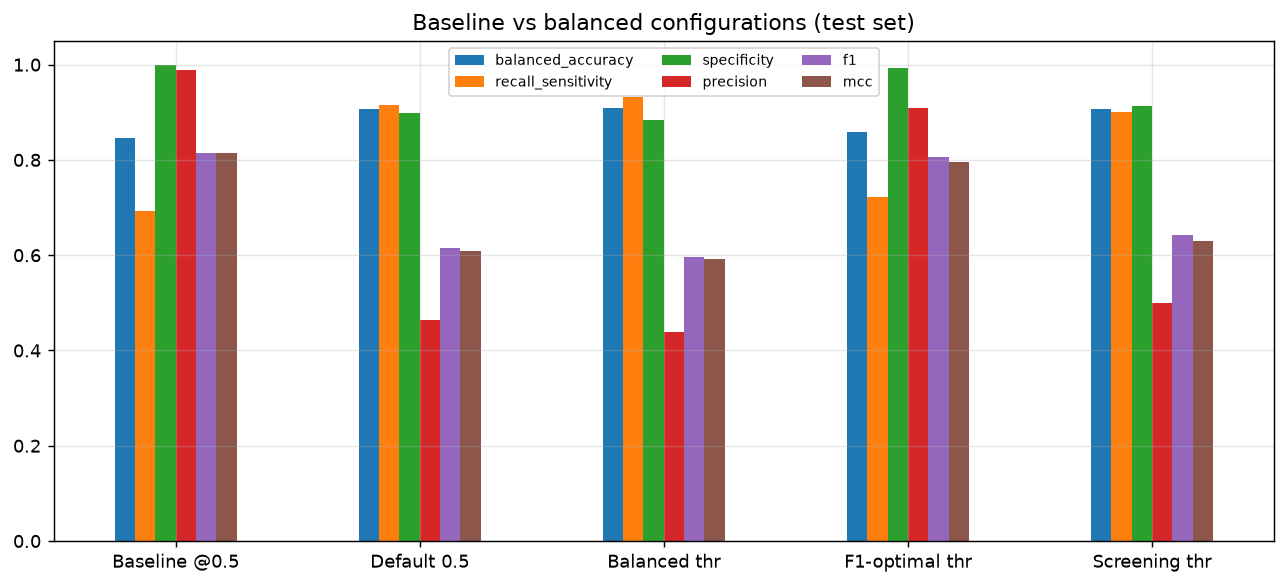

In [25]:

# FIGURES

%matplotlib inline

import matplotlib.pyplot as plt
from IPython.display import display

plt.rcParams.update({
    "figure.dpi": 130,
    "axes.grid": True,
    "grid.alpha": .3
})


# 1. ROC + Precision-Recall Curves

fig, ax = plt.subplots(1, 2, figsize=(11, 4.4))

for lab, pp in [
    ("Baseline (no balancing)", p_base),
    (f"{BEST_MODEL}+{BEST_STRAT}", p_test)
]:

    fpr, tpr, _ = roc_curve(y_test, pp)

    ax[0].plot(
        fpr,
        tpr,
        label=f"{lab} (AUC={roc_auc_score(y_test, pp):.3f})"
    )

    pr, rc, _ = precision_recall_curve(y_test, pp)

    ax[1].plot(
        rc,
        pr,
        label=f"{lab} (AP={average_precision_score(y_test, pp):.3f})"
    )


ax[0].plot([0, 1], [0, 1], "k--", lw=.8)

ax[0].set(
    xlabel="False positive rate",
    ylabel="True positive rate",
    title="ROC curve (test)"
)

ax[1].axhline(
    y_test.mean(),
    color="k",
    ls="--",
    lw=.8
)

ax[1].set(
    xlabel="Recall",
    ylabel="Precision",
    title="Precision-Recall curve (test)"
)

ax[0].legend(loc="lower right")
ax[1].legend(loc="lower left")

plt.tight_layout()

# Save
plt.savefig(
    FIG / "roc_pr_curves.png",
    bbox_inches="tight"
)

# DISPLAY IN JUPYTER
display(fig)

plt.close(fig)


# 2. Threshold Trade-off

grid = np.linspace(0.02, 0.98, 97)

sens = [
    recall_score(
        y_test,
        (p_test >= t).astype(int)
    )
    for t in grid
]

spec = [
    metrics_at(
        y_test,
        p_test,
        t
    )["specificity"]
    for t in grid
]

prec = [
    precision_score(
        y_test,
        (p_test >= t).astype(int),
        zero_division=0
    )
    for t in grid
]

f1s = [
    f1_score(
        y_test,
        (p_test >= t).astype(int)
    )
    for t in grid
]


fig2, ax2 = plt.subplots(figsize=(7.5, 4.6))

for v, l in [
    (sens, "Sensitivity (recall)"),
    (spec, "Specificity"),
    (prec, "Precision"),
    (f1s, "F1")
]:
    ax2.plot(grid, v, label=l)


ax2.axvline(
    bal_thr,
    color="k",
    ls=":",
    label=f"chosen threshold = {bal_thr:.2f}"
)

ax2.set_xlabel("Decision threshold")
ax2.set_ylabel("Score")
ax2.set_title("Threshold trade-off (test set)")
ax2.legend()

plt.tight_layout()

# Save
plt.savefig(
    FIG / "threshold_tradeoff.png",
    bbox_inches="tight"
)

# DISPLAY IN JUPYTER
display(fig2)

plt.close(fig2)


# 3. Confusion Matrices

fig3, ax = plt.subplots(
    1,
    3,
    figsize=(13, 3.8)
)

configs = [
    ("Baseline @0.5", p_base, 0.5),

    ("Balanced threshold", p_test, bal_thr),

    (
        "Screening (recall>=90%)",
        p_test,
        THRESHOLDS["screening (recall>=90%)"]
    )
]


for a, (title, pp, thr) in zip(ax, configs):

    cm = confusion_matrix(
        y_test,
        (pp >= thr).astype(int)
    )

    a.imshow(
        cm,
        cmap="Blues"
    )

    a.set_title(
        f"{title}\nthr={thr:.2f}"
    )

    a.grid(False)

    a.set_xticks(
        [0, 1],
        ["No DM", "DM"]
    )

    a.set_yticks(
        [0, 1],
        ["No DM", "DM"]
    )

    a.set_xlabel("Predicted")
    a.set_ylabel("Actual")

    for (i, j), v in np.ndenumerate(cm):

        a.text(
            j,
            i,
            f"{v:,}",
            ha="center",
            va="center",
            color=(
                "white"
                if v > cm.max() / 2
                else "black"
            )
        )


plt.tight_layout()

# Save
plt.savefig(
    FIG / "confusion_matrices.png",
    bbox_inches="tight"
)

# DISPLAY IN JUPYTER
display(fig3)

plt.close(fig3)


# 4. Baseline vs Balanced Configurations

bars = final_df.set_index("config")[
    [
        "balanced_accuracy",
        "recall_sensitivity",
        "specificity",
        "precision",
        "f1",
        "mcc"
    ]
]

bars.index = [
    "Baseline @0.5",
    "Default 0.5",
    "Balanced thr",
    "F1-optimal thr",
    "Screening thr"
]


fig4, ax4 = plt.subplots(
    figsize=(10, 4.6)
)

bars.plot(
    kind="bar",
    ax=ax4
)

ax4.set_ylim(0, 1.05)
ax4.set_xticklabels(
    bars.index,
    rotation=0
)

ax4.set_title(
    "Baseline vs balanced configurations (test set)"
)

ax4.legend(
    ncol=3,
    fontsize=8
)

plt.tight_layout()

# Save
plt.savefig(
    FIG / "baseline_vs_balanced.png",
    bbox_inches="tight"
)

# DISPLAY IN JUPYTER
display(fig4)

plt.close(fig4)

In [23]:

# ---------------------------------------------------------------------------- save model
bundle = {
    "pipeline": final,
    "threshold": THRESHOLDS["balanced (max balanced-accuracy)"],
    "thresholds": THRESHOLDS,
    "model": BEST_MODEL, "imbalance_strategy": BEST_STRAT,
    "features": NUM + BIN + CAT,
    "note": "Trained on the training split only. Threshold chosen from out-of-fold training predictions.",
}
joblib.dump(bundle, ROOT / "diabetes_model_balanced.pkl")
json.dump({"selected": [BEST_MODEL, BEST_STRAT], "thresholds": THRESHOLDS,
           "test_threshold_free": test_tf}, open(OUT / "summary.json", "w"), indent=2)
print("\nDONE. model + results + figures saved.", flush=True)



DONE. model + results + figures saved.
